In [12]:
import os
import json
import matplotlib.pyplot as plt

import xarray as xr
import seaborn as sns
import pandas as pd
import numpy as np
from pypalettes import load_cmap

import functions.eddy_feedback as ef

In [13]:
df = pd.read_csv('/home/links/ct715/eddy_feedback/chapter1/zz_paper_plots/data/pamip_k_efp_winters.csv')
df

,model,efp_nh,efp_nh_gt3,efp_nh_123,efp_sh,efp_sh_gt3,efp_sh_123
0,AWI-CM-1-1-MR,0.2592,0.1931,0.0607,0.2557,0.2325,0.0223
1,CNRM-CM6-1,0.2244,0.1286,0.0827,0.1944,0.1805,0.0132
2,CanESM5,0.3133,0.1771,0.1232,0.3271,0.2758,0.0195
3,FGOALS-f3-L,0.2353,0.1231,0.0731,0.1273,0.1061,0.0114
4,HadGEM3-GC31-LL,0.1735,0.1072,0.0529,0.1729,0.1528,0.0160
5,HadGEM3-GC31-MM,0.2525,0.1087,0.1022,0.1874,0.1544,0.0140
6,IPSL-CM6A-LR,0.2623,0.1947,0.0654,0.2015,0.1938,0.0179
7,MIROC6,0.1592,0.1045,0.0425,0.2058,0.1458,0.0273


In [14]:
# Load custom colormap
cmap = load_cmap("highcontrast")
palette = cmap.colors


---

# Reanalysis error bars

In [15]:
import pandas as pd
import numpy as np

BOOTSTRAP_CSV = '/home/links/ct715/eddy_feedback/chapter1/daily_efp/bootstrap/data/reanalysis/efp_full/jra55_efp_bootstrap_summary_efp_full.csv'

VAR_SEASON_TO_LABEL = {
    ('div1_QG',     'DJF'): 'EFP_nh_total',
    ('div1_QG_gt3', 'DJF'): 'EFP_nh_k>3',
    ('div1_QG_123', 'DJF'): 'EFP_nh_k123',
    ('div1_QG',     'JAS'): 'EFP_sh_total',
    ('div1_QG_gt3', 'JAS'): 'EFP_sh_k>3',
    ('div1_QG_123', 'JAS'): 'EFP_sh_k123',
}

_csv = pd.read_csv(BOOTSTRAP_CSV)
time_freq = 'daily'
period = '1979_2016'

records = []
for (var, season), label in VAR_SEASON_TO_LABEL.items():
    case = f'{period}_{time_freq}_{var}'
    row  = _csv[(_csv['case'] == case) & (_csv['season'] == season)]
    if row.empty:
        print(f"Warning: no bootstrap data for {case} {season}")
        continue
    mean, std = row['efp_mean'].values[0], row['efp_std'].values[0]
    records.append({'efp_type': label, 'efp_mean': mean, 'efp_std': std})
    print(f"{label} ({case}): {mean:.3f}  [{mean - std:.3f}, {mean + std:.3f}]")

bootstrap_df = pd.DataFrame(records)
bootstrap_df

EFP_nh_total (1979_2016_daily_div1_QG): 0.357  [0.306, 0.407]
EFP_nh_k>3 (1979_2016_daily_div1_QG_gt3): 0.161  [0.124, 0.198]
EFP_nh_k123 (1979_2016_daily_div1_QG_123): 0.179  [0.141, 0.218]
EFP_sh_total (1979_2016_daily_div1_QG): 0.219  [0.188, 0.251]
EFP_sh_k>3 (1979_2016_daily_div1_QG_gt3): 0.201  [0.167, 0.235]
EFP_sh_k123 (1979_2016_daily_div1_QG_123): 0.056  [0.041, 0.071]


,efp_type,efp_mean,efp_std
0,EFP_nh_total,0.356805,0.050328
1,EFP_nh_k>3,0.160699,0.037180
2,EFP_nh_k123,0.179489,0.038416
3,EFP_sh_total,0.219424,0.031819
4,EFP_sh_k>3,0.201028,0.034098
5,EFP_sh_k123,0.055882,0.014917


/emmy-noether/home/ct715/miniforge3/envs/eddy/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/emmy-noether/home/ct715/miniforge3/envs/eddy/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/emmy-noether/home/ct715/miniforge3/envs/eddy/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


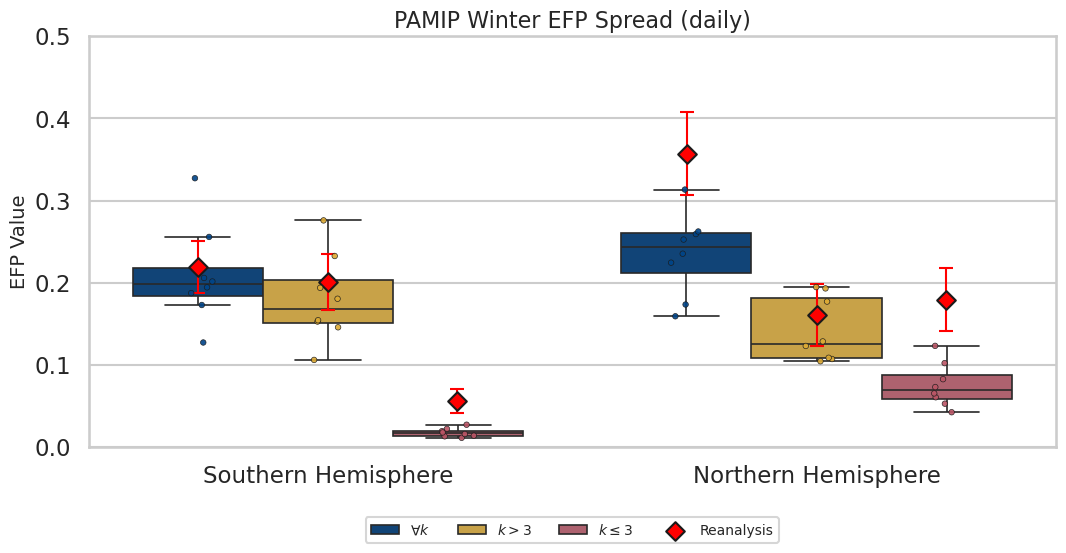

In [17]:
# Convert to discrete palette for seaborn
# Melt to long format for seaborn
df_long = df.melt(
    id_vars="model",
    value_vars=["efp_nh", "efp_nh_gt3", "efp_nh_123", "efp_sh", "efp_sh_gt3", "efp_sh_123"],
    var_name="hemisphere_dataset", value_name="efp"
)
# Split hemisphere and dataset info
df_long[['hemisphere', 'dataset']] = df_long['hemisphere_dataset'].str.extract(r'efp_(nh|sh)(_.*)?')
df_long['dataset'] = df_long['dataset'].replace({None: '$\\forall k$', '_gt3': '$k>3$', '_123': '$k \\leq 3$'})

# Set general style and context (no palette override)
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(11, 6))

# Boxplot - specify order to put SH first
sns.boxplot(
    data=df_long,
    x='hemisphere', y='efp', hue='dataset',
    order=['sh', 'nh'],
    linewidth=1.2, showfliers=False,
    palette=palette
)
# Overlay stripplot - specify same order
sns.stripplot(
    data=df_long,
    x='hemisphere', y='efp', hue='dataset',
    order=['sh', 'nh'],
    dodge=True, alpha=0.9, size=4, jitter=True,
    marker="o", linewidth=0.5, edgecolor='k',
    palette=palette, zorder=11
)

# --- Helper functions to pull from bootstrap_df ---
def _mean(efp_type):
    return bootstrap_df[bootstrap_df['efp_type'] == efp_type]['efp_mean'].values[0]

def _std(efp_type):
    return bootstrap_df[bootstrap_df['efp_type'] == efp_type]['efp_std'].values[0]

# --- Add custom points with error bars ---
points = {
    ("NH", "total"): _mean('EFP_nh_total'),
    ("NH", "k>3"):   _mean('EFP_nh_k>3'),
    ("NH", "k123"):  _mean('EFP_nh_k123'),
    ("SH", "total"): _mean('EFP_sh_total'),
    ("SH", "k>3"):   _mean('EFP_sh_k>3'),
    ("SH", "k123"):  _mean('EFP_sh_k123'),
}
errors = {
    ("NH", "total"): _std('EFP_nh_total'),
    ("NH", "k>3"):   _std('EFP_nh_k>3'),
    ("NH", "k123"):  _std('EFP_nh_k123'),
    ("SH", "total"): _std('EFP_sh_total'),
    ("SH", "k>3"):   _std('EFP_sh_k>3'),
    ("SH", "k123"):  _std('EFP_sh_k123'),
}

ax = plt.gca()

positions = {
    ("SH", "total"): -0.265,
    ("SH", "k>3"):  0.0,
    ("SH", "k123"):  0.265,
    ("NH", "total"):  0.735,
    ("NH", "k>3"):  1.0,
    ("NH", "k123"):  1.265,
}

for (hemi, dataset), value in points.items():
    x = positions[(hemi, dataset)]
    error = errors[(hemi, dataset)]
    ax.errorbar(x, value, yerr=error, color='red', capsize=5, capthick=1.5,
                elinewidth=1.5, zorder=9)
    ax.scatter(x, value, color='red', s=90, edgecolor='k', zorder=10, marker='D')

# Labels and title
plt.ylim(0, 0.5)
plt.xlabel("")
plt.ylabel("EFP Value", fontsize=14)
plt.xticks([0, 1], ["Southern Hemisphere", "Northern Hemisphere"])

# --- Custom legend ---
handles, labels = ax.get_legend_handles_labels()
unique_handles = handles[0:3]
unique_labels = labels[0:3]
diamond_handle = plt.scatter([], [], color='red', edgecolor='k', marker='D', s=90, label='Reanalysis')
unique_handles.append(diamond_handle)
unique_labels.append('Reanalysis')

plt.title('PAMIP Winter EFP Spread (daily)', fontsize=16)

plt.legend(unique_handles, unique_labels,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.25),
           ncol=4, fontsize=10, title_fontsize=11)
plt.tight_layout()

# plt.savefig('./plots/spatial_scale_efp_pamip_bw.png', dpi=300, bbox_inches='tight')
plt.show()